# Q10

In [17]:
import subprocess
subprocess.run(["pip", "install", "matplotlib", "numpy"], check=True)
print("Done!")

Done!


In [18]:
from datetime import datetime
print(datetime.now())
print("F23-0885")

2026-03-15 19:07:50.228676
F23-0885


In [1]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")

import random
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return -(x - 3)**2 + 9

STEP = 0.1
print("--------------------------------------------------------------")
print(f"f(0) = {f(0)}")
print(f"f(3) = {f(3)}  <- should be 9 (global max)")
print(f"f(6) = {f(6)}")
print("--------------------------------------------------------------")


2026-03-16 22:47:10.487807
F23-0885
--------------------------------------------------------------
--------------------------------------------------------------
f(0) = 0
f(3) = 9  <- should be 9 (global max)
f(6) = 0
--------------------------------------------------------------


# (A)

In [2]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")

def simple_hill_climbing(start=0.0, step=STEP):
    x = start
    path = [x]
    print("=== Simple Hill Climbing ===")
    print(f"Start: x={x:.4f}, f(x)={f(x):.4f}")
    while True:
        moved = False
        for neighbour in [x + step, x - step]:
            if f(neighbour) > f(x):
                x = neighbour
                path.append(x)
                print("----------------------------------------------")

                print(f"  -> moved to x={x:.4f}, f(x)={f(x):.4f}")
                moved = True
                break
        if not moved:
            print(f"\nNo improvement found.")
            break
    print(f"\nFinal: x={x:.4f}, f(x)={f(x):.4f} | Steps: {len(path)-1}")
    return x, path

sol_a, path_a = simple_hill_climbing(start=0.0)

2026-03-16 22:47:38.428524
F23-0885
--------------------------------------------------------------
=== Simple Hill Climbing ===
Start: x=0.0000, f(x)=0.0000
----------------------------------------------
  -> moved to x=0.1000, f(x)=0.5900
----------------------------------------------
  -> moved to x=0.2000, f(x)=1.1600
----------------------------------------------
  -> moved to x=0.3000, f(x)=1.7100
----------------------------------------------
  -> moved to x=0.4000, f(x)=2.2400
----------------------------------------------
  -> moved to x=0.5000, f(x)=2.7500
----------------------------------------------
  -> moved to x=0.6000, f(x)=3.2400
----------------------------------------------
  -> moved to x=0.7000, f(x)=3.7100
----------------------------------------------
  -> moved to x=0.8000, f(x)=4.1600
----------------------------------------------
  -> moved to x=0.9000, f(x)=4.5900
----------------------------------------------
  -> moved to x=1.0000, f(x)=5.0000
-------------

# (B)

In [3]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")

def steepest_ascent_hill_climbing(start=0.0, step=STEP):
    x = start
    path = [x]
    print("=== Steepest-Ascent Hill Climbing ===")
    print(f"Start: x={x:.4f}, f(x)={f(x):.4f}")
    while True:
        right = x + step
        left  = x - step
        best  = right if f(right) >= f(left) else left
        if f(best) > f(x):
            x = best
            path.append(x)
            print("----------------------------------------------")
            print(f"  -> moved to x={x:.4f}, f(x)={f(x):.4f}")
        else:
            print(f"\nTerminated")
            break
    print(f"\nFinal: x={x:.4f}, f(x)={f(x):.4f} | Steps: {len(path)-1}")
    return x, path

sol_b, path_b = steepest_ascent_hill_climbing(start=0.0)

2026-03-16 22:56:33.815613
F23-0885
--------------------------------------------------------------
=== Steepest-Ascent Hill Climbing ===
Start: x=0.0000, f(x)=0.0000
----------------------------------------------
  -> moved to x=0.1000, f(x)=0.5900
----------------------------------------------
  -> moved to x=0.2000, f(x)=1.1600
----------------------------------------------
  -> moved to x=0.3000, f(x)=1.7100
----------------------------------------------
  -> moved to x=0.4000, f(x)=2.2400
----------------------------------------------
  -> moved to x=0.5000, f(x)=2.7500
----------------------------------------------
  -> moved to x=0.6000, f(x)=3.2400
----------------------------------------------
  -> moved to x=0.7000, f(x)=3.7100
----------------------------------------------
  -> moved to x=0.8000, f(x)=4.1600
----------------------------------------------
  -> moved to x=0.9000, f(x)=4.5900
----------------------------------------------
  -> moved to x=1.0000, f(x)=5.0000
----

# (C)

In [4]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")

def random_restart_hill_climbing(num_restarts=10, step=STEP, low=-10, high=10, seed=42):
    print("=== Random-Restart Hill Climbing ===")
    random.seed(seed)
    best_x=None; best_fx=float('-inf'); best_start=None
    all_paths=[]; all_starts=[]

    for i in range(num_restarts):
        start = random.uniform(low, high)
        all_starts.append(start)
        x = start; path = [x]
        while True:
            right = x + step; left = x - step
            best  = right if f(right) >= f(left) else left
            if f(best) > f(x):
                x = best; path.append(x)
            else:
                break
        all_paths.append(path)
        print("----------------------------------------------")
        print(f"Restart {i+1:02d}: start={start:7.3f} -> x={x:.4f}, f(x)={f(x):.4f}")
        if f(x) > best_fx:
            best_fx=f(x); best_x=x; best_start=start

    print(f"\n{'='*45}")
    print(f" Best x        : {best_x:.4f}")
    print(f" Best f(x)     : {best_fx:.4f}")
    print(f" Best start x0 : {best_start:.4f}")
    print(f"{'='*45}")
    return best_x, best_fx, best_start, all_paths, all_starts

best_x, best_fx, best_start, all_paths, all_starts = random_restart_hill_climbing()

2026-03-16 22:56:54.663552
F23-0885
--------------------------------------------------------------
=== Random-Restart Hill Climbing ===
----------------------------------------------
Restart 01: start=  2.789 -> x=2.9885, f(x)=8.9999
----------------------------------------------
Restart 02: start= -9.500 -> x=3.0002, f(x)=9.0000
----------------------------------------------
Restart 03: start= -4.499 -> x=3.0006, f(x)=9.0000
----------------------------------------------
Restart 04: start= -5.536 -> x=2.9642, f(x)=8.9987
----------------------------------------------
Restart 05: start=  4.729 -> x=3.0294, f(x)=8.9991
----------------------------------------------
Restart 06: start=  3.534 -> x=3.0340, f(x)=8.9988
----------------------------------------------
Restart 07: start=  7.844 -> x=3.0436, f(x)=8.9981
----------------------------------------------
Restart 08: start= -8.261 -> x=3.0388, f(x)=8.9985
----------------------------------------------
Restart 09: start= -1.562 -> x=3.

# (D)

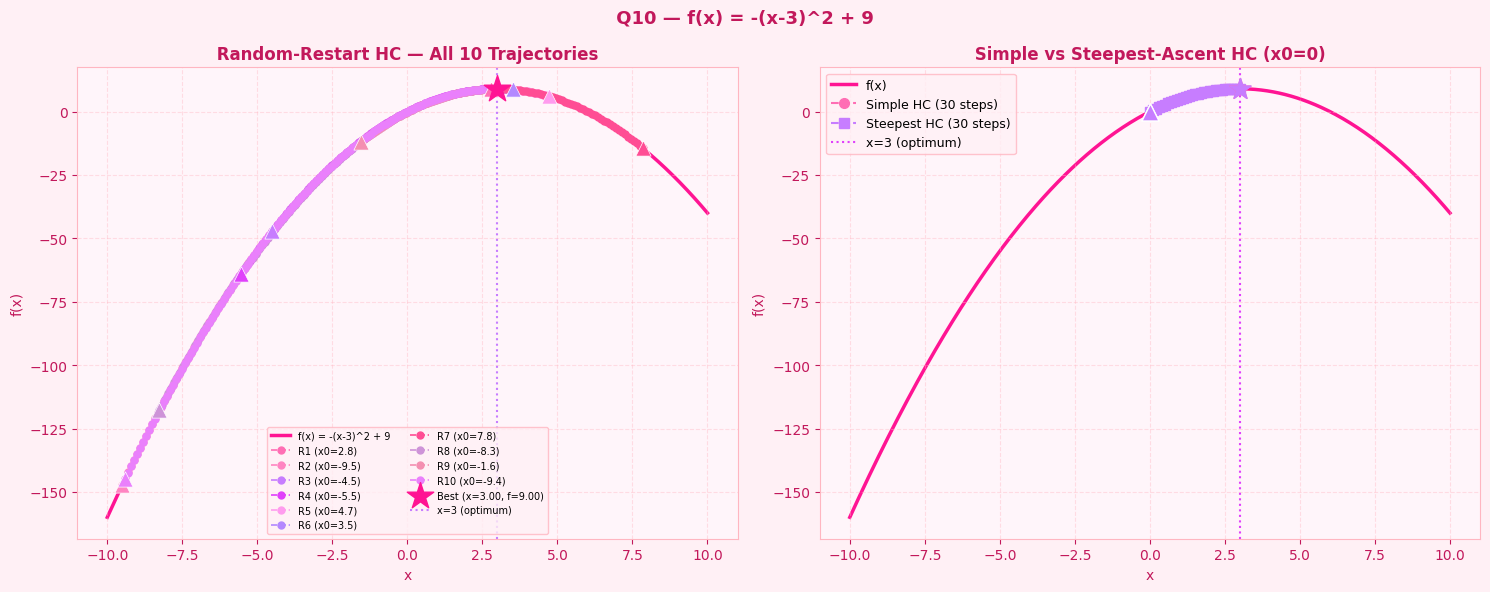

Graph saved: q10_hill_climbing.png 


In [35]:
x_range = np.linspace(-10, 10, 500)
y_range = [f(x) for x in x_range]

colors = [
    '#FF6EB4', '#FF85C2', '#C77DFF', '#E040FB', '#FF9CEE',
    '#B388FF', '#FF4D94', '#CE93D8', '#F48FB1', '#EA80FC',
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#FFF0F5')
axes[0].set_facecolor('#FFF5FA')
axes[1].set_facecolor('#FFF5FA')

axes[0].plot(x_range, y_range, color='#FF1493', linewidth=2.5,
             label='f(x) = -(x-3)^2 + 9', zorder=1)

for i, (path, start) in enumerate(zip(all_paths, all_starts)):
    xs = path; ys = [f(x) for x in xs]; c = colors[i % 10]
    axes[0].plot(xs, ys, 'o--', color=c, markersize=5, linewidth=1.2,
                 label=f'R{i+1} (x0={start:.1f})', zorder=2)
    axes[0].scatter(xs[0], ys[0], color=c, marker='^', s=120, zorder=4,
                    edgecolors='white', linewidths=0.5)

axes[0].scatter(best_x, best_fx, color='#FF1493', marker='*', s=400, zorder=5,
                label=f'Best (x={best_x:.2f}, f={best_fx:.2f})')
axes[0].axvline(x=3, color='#C77DFF', linestyle=':', linewidth=1.5, label='x=3 (optimum)')
axes[0].set_title(' Random-Restart HC — All 10 Trajectories ', fontsize=12,
                  color='#C2185B', fontweight='bold')
axes[0].set_xlabel('x', color='#C2185B')
axes[0].set_ylabel('f(x)', color='#C2185B')
axes[0].tick_params(colors='#C2185B')
axes[0].legend(loc='lower center', fontsize=7, ncol=2,
               facecolor='#FFF0F5', edgecolor='#FFB6C1')
axes[0].grid(True, color='#FFB6C1', alpha=0.4, linestyle='--')
axes[0].spines['top'].set_color('#FFB6C1')
axes[0].spines['right'].set_color('#FFB6C1')
axes[0].spines['left'].set_color('#FFB6C1')
axes[0].spines['bottom'].set_color('#FFB6C1')

axes[1].plot(x_range, y_range, color='#FF1493', linewidth=2.5,
             label='f(x)', zorder=1)

xs_a = path_a; ys_a = [f(x) for x in xs_a]
axes[1].plot(xs_a, ys_a, 'o--', color='#FF6EB4', markersize=7, linewidth=1.5,
             label=f'Simple HC ({len(path_a)-1} steps)')
axes[1].scatter(xs_a[0], ys_a[0], color='#FF6EB4', marker='^', s=150, zorder=5,
                edgecolors='white')
axes[1].scatter(xs_a[-1], ys_a[-1], color='#FF6EB4', marker='*', s=250, zorder=5)

xs_b = path_b; ys_b = [f(x) for x in xs_b]
axes[1].plot(xs_b, ys_b, 's--', color='#C77DFF', markersize=7, linewidth=1.5,
             label=f'Steepest HC ({len(path_b)-1} steps)')
axes[1].scatter(xs_b[0], ys_b[0], color='#C77DFF', marker='^', s=150, zorder=5,
                edgecolors='white')
axes[1].scatter(xs_b[-1], ys_b[-1], color='#C77DFF', marker='*', s=250, zorder=5)

axes[1].axvline(x=3, color='#E040FB', linestyle=':', linewidth=1.5, label='x=3 (optimum)')
axes[1].set_title(' Simple vs Steepest-Ascent HC (x0=0) ', fontsize=12,
                  color='#C2185B', fontweight='bold')
axes[1].set_xlabel('x', color='#C2185B')
axes[1].set_ylabel('f(x)', color='#C2185B')
axes[1].tick_params(colors='#C2185B')
axes[1].legend(fontsize=9, facecolor='#FFF0F5', edgecolor='#FFB6C1')
axes[1].grid(True, color='#FFB6C1', alpha=0.4, linestyle='--')
axes[1].spines['top'].set_color('#FFB6C1')
axes[1].spines['right'].set_color('#FFB6C1')
axes[1].spines['left'].set_color('#FFB6C1')
axes[1].spines['bottom'].set_color('#FFB6C1')

plt.suptitle(' Q10 — f(x) = -(x-3)^2 + 9 ', fontsize=13,
             fontweight='bold', color='#C2185B')
plt.tight_layout()
plt.savefig('q10_hill_climbing.png', dpi=150, bbox_inches='tight', facecolor='#FFF0F5')
plt.show()
print("Graph saved: q10_hill_climbing.png ")

Does random restart always help?
- No for unimodal functions like f(x) = -(x-3)^2 + 9 
  every start leads to the same optimum anyway
  
When is it wasteful?
- Simple smooth functions with one peak
- When computation is expensive
- When all starts land in the same region

# Q11

In [5]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")

import math

CITIES = [(0,0),(1,5),(3,2),(6,4),(8,1),(7,7),(4,9),(2,7),(5,5),(9,3)]
NUM_CITIES = len(CITIES)
T0 = 1000; ALPHA = 0.995; ITERATIONS = 10000

print(f"Cities: {CITIES}")
print(f"T0={T0}, alpha={ALPHA}, iterations={ITERATIONS}")

2026-03-16 22:57:06.822088
F23-0885
--------------------------------------------------------------
Cities: [(0, 0), (1, 5), (3, 2), (6, 4), (8, 1), (7, 7), (4, 9), (2, 7), (5, 5), (9, 3)]
T0=1000, alpha=0.995, iterations=10000


# (A)

In [6]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")

def euclidean(c1, c2):
    return math.sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2)

def tour_cost(tour, cities=CITIES):
    n = len(tour)
    return sum(euclidean(cities[tour[i]], cities[tour[(i+1)%n]]) for i in range(n))

def get_neighbour(tour):
    new_tour = tour[:]
    i, j = random.sample(range(len(new_tour)), 2)
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour

def random_tour(n=NUM_CITIES):
    t = list(range(n)); random.shuffle(t); return t

random.seed(42)
demo = random_tour()
print("----------------------------------------------")
print(f"Sample tour  : {demo}")
print(f"Tour cost    : {tour_cost(demo):.4f}")
print(f"Neighbour    : {get_neighbour(demo)}")
print("----------------------------------------------")


2026-03-16 22:57:11.413892
F23-0885
--------------------------------------------------------------
----------------------------------------------
Sample tour  : [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
Tour cost    : 44.0887
Neighbour    : [7, 3, 2, 8, 5, 6, 1, 4, 0, 9]
----------------------------------------------


# (B)

In [7]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")

def simulated_annealing(cities=CITIES, T0=T0, iterations=ITERATIONS,
                         cooling='geometric', alpha=ALPHA, seed=42):
    random.seed(seed)
    current_tour = random_tour(len(cities))
    current_cost = tour_cost(current_tour, cities)
    best_tour    = current_tour[:]
    best_cost    = current_cost
    T            = T0
    cost_history = [current_cost]
    best_history = [best_cost]
    temp_history = [T]
    linear_step  = T0 / iterations

    for i in range(1, iterations + 1):
        new_tour = get_neighbour(current_tour)
        new_cost = tour_cost(new_tour, cities)
        delta_E  = new_cost - current_cost

        if delta_E < 0:
            current_tour = new_tour; current_cost = new_cost
        else:
            prob = math.exp(-delta_E / T) if T > 1e-10 else 0
            if random.random() < prob:
                current_tour = new_tour; current_cost = new_cost

        if current_cost < best_cost:
            best_cost = current_cost; best_tour = current_tour[:]

        T = T * alpha if cooling == 'geometric' else max(T0 - linear_step * i, 1e-10)
        cost_history.append(current_cost)
        best_history.append(best_cost)
        temp_history.append(T)

    return best_tour, best_cost, cost_history, best_history, temp_history
print("--------------------------------------------------------------")
print("SA function ready Cooling options: 'geometric' and 'linear'")
print("--------------------------------------------------------------")


2026-03-16 22:57:15.969432
F23-0885
--------------------------------------------------------------
--------------------------------------------------------------
SA function ready Cooling options: 'geometric' and 'linear'
--------------------------------------------------------------


# (C)

In [8]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")
best_tour_geo, best_cost_geo, cost_hist_geo, best_hist_geo, temp_hist_geo = \
    simulated_annealing(cooling='geometric')

print("="*50)
print("RESULTS — Geometric Cooling")
print("="*50)
print(f"Best Tour   : {best_tour_geo}")
for idx, city_idx in enumerate(best_tour_geo):
    arrow = " ->" if idx < len(best_tour_geo)-1 else " -> (back to start)"
    print("--------------------------------------------------------------")
    print(f"  Step {idx+1}: City {city_idx} {CITIES[city_idx]}{arrow}")
print(f"\nTotal Distance : {best_cost_geo:.4f}")
print("="*50)

2026-03-16 22:57:19.722500
F23-0885
--------------------------------------------------------------
RESULTS — Geometric Cooling
Best Tour   : [3, 9, 4, 2, 0, 1, 7, 6, 5, 8]
--------------------------------------------------------------
  Step 1: City 3 (6, 4) ->
--------------------------------------------------------------
  Step 2: City 9 (9, 3) ->
--------------------------------------------------------------
  Step 3: City 4 (8, 1) ->
--------------------------------------------------------------
  Step 4: City 2 (3, 2) ->
--------------------------------------------------------------
  Step 5: City 0 (0, 0) ->
--------------------------------------------------------------
  Step 6: City 1 (1, 5) ->
--------------------------------------------------------------
  Step 7: City 7 (2, 7) ->
--------------------------------------------------------------
  Step 8: City 6 (4, 9) ->
--------------------------------------------------------------
  Step 9: City 5 (7, 7) ->
------------------

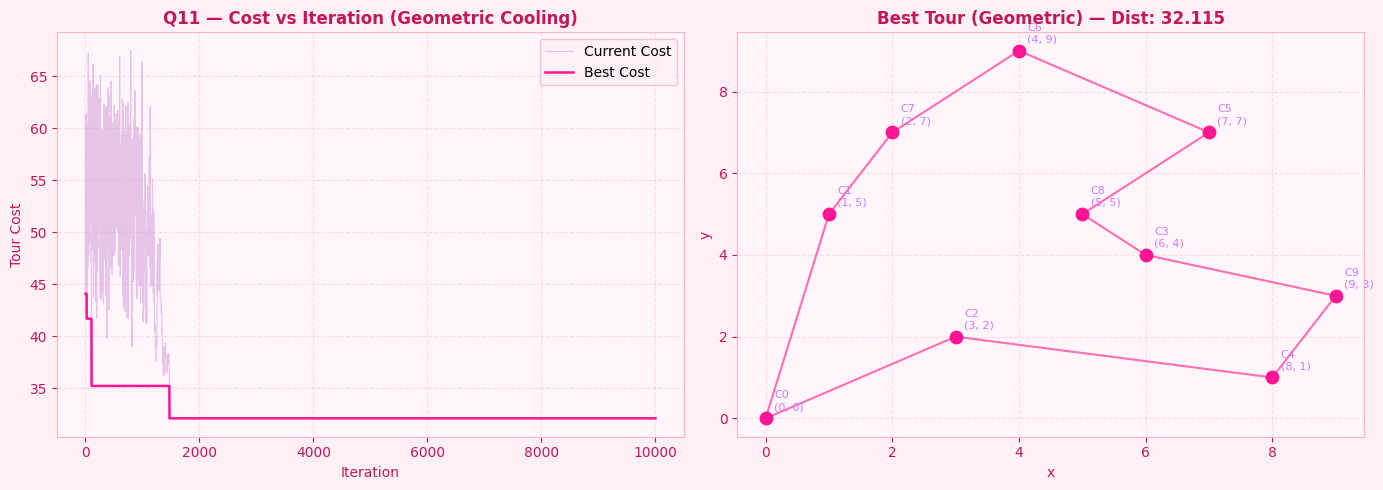

Graph saved: q11_geometric.png 


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FFF0F5')
axes[0].set_facecolor('#FFF5FA')
axes[1].set_facecolor('#FFF5FA')

axes[0].plot(cost_hist_geo, color='#CE93D8', alpha=0.5, linewidth=0.8, label='Current Cost')
axes[0].plot(best_hist_geo, color='#FF1493', linewidth=1.8, label='Best Cost')
axes[0].set_title('Q11 — Cost vs Iteration (Geometric Cooling)', fontsize=12,
                  color='#C2185B', fontweight='bold')
axes[0].set_xlabel('Iteration', color='#C2185B')
axes[0].set_ylabel('Tour Cost', color='#C2185B')
axes[0].tick_params(colors='#C2185B')
axes[0].legend(facecolor='#FFF0F5', edgecolor='#FFB6C1')
axes[0].grid(True, color='#FFB6C1', alpha=0.4, linestyle='--')
axes[0].spines['top'].set_color('#FFB6C1')
axes[0].spines['right'].set_color('#FFB6C1')
axes[0].spines['left'].set_color('#FFB6C1')
axes[0].spines['bottom'].set_color('#FFB6C1')

tour_coords = [CITIES[i] for i in best_tour_geo] + [CITIES[best_tour_geo[0]]]
xs = [c[0] for c in tour_coords]; ys = [c[1] for c in tour_coords]
axes[1].plot(xs, ys, '-o', color='#FF6EB4', markersize=8, linewidth=1.5)
for idx, city_idx in enumerate(best_tour_geo):
    cx, cy = CITIES[city_idx]
    axes[1].annotate(f'C{city_idx}\n{CITIES[city_idx]}', (cx, cy),
                     textcoords='offset points', xytext=(6,6), fontsize=8, color='#C77DFF')
axes[1].scatter(*zip(*CITIES), color='#FF1493', zorder=5, s=80)
axes[1].set_title(f'Best Tour (Geometric) — Dist: {best_cost_geo:.3f}', fontsize=12,
                  color='#C2185B', fontweight='bold')
axes[1].set_xlabel('x', color='#C2185B')
axes[1].set_ylabel('y', color='#C2185B')
axes[1].tick_params(colors='#C2185B')
axes[1].grid(True, color='#FFB6C1', alpha=0.4, linestyle='--')
axes[1].spines['top'].set_color('#FFB6C1')
axes[1].spines['right'].set_color('#FFB6C1')
axes[1].spines['left'].set_color('#FFB6C1')
axes[1].spines['bottom'].set_color('#FFB6C1')

plt.tight_layout()
plt.savefig('q11_geometric.png', dpi=150, bbox_inches='tight', facecolor='#FFF0F5')
plt.show()
print("Graph saved: q11_geometric.png ")

# (D)

In [9]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")
best_tour_lin, best_cost_lin, cost_hist_lin, best_hist_lin, temp_hist_lin = \
    simulated_annealing(cooling='linear')

print("="*50)
print("COMPARISON — Geometric vs Linear")
print("="*50)
print(f"Geometric -> Best Cost : {best_cost_geo:.4f} | Tour: {best_tour_geo}")
print("--------------------------------------------------------------")
print(f"Linear    -> Best Cost : {best_cost_lin:.4f} | Tour: {best_tour_lin}")
print("--------------------------------------------------------------")

winner = 'Geometric' if best_cost_geo < best_cost_lin else 'Linear'
print(f"\nWinner (lower cost) : {winner}")
print("="*50)

2026-03-16 22:57:28.351263
F23-0885
--------------------------------------------------------------
COMPARISON — Geometric vs Linear
Geometric -> Best Cost : 32.1146 | Tour: [3, 9, 4, 2, 0, 1, 7, 6, 5, 8]
--------------------------------------------------------------
Linear    -> Best Cost : 34.6802 | Tour: [7, 6, 5, 9, 4, 3, 8, 0, 2, 1]
--------------------------------------------------------------

Winner (lower cost) : Geometric


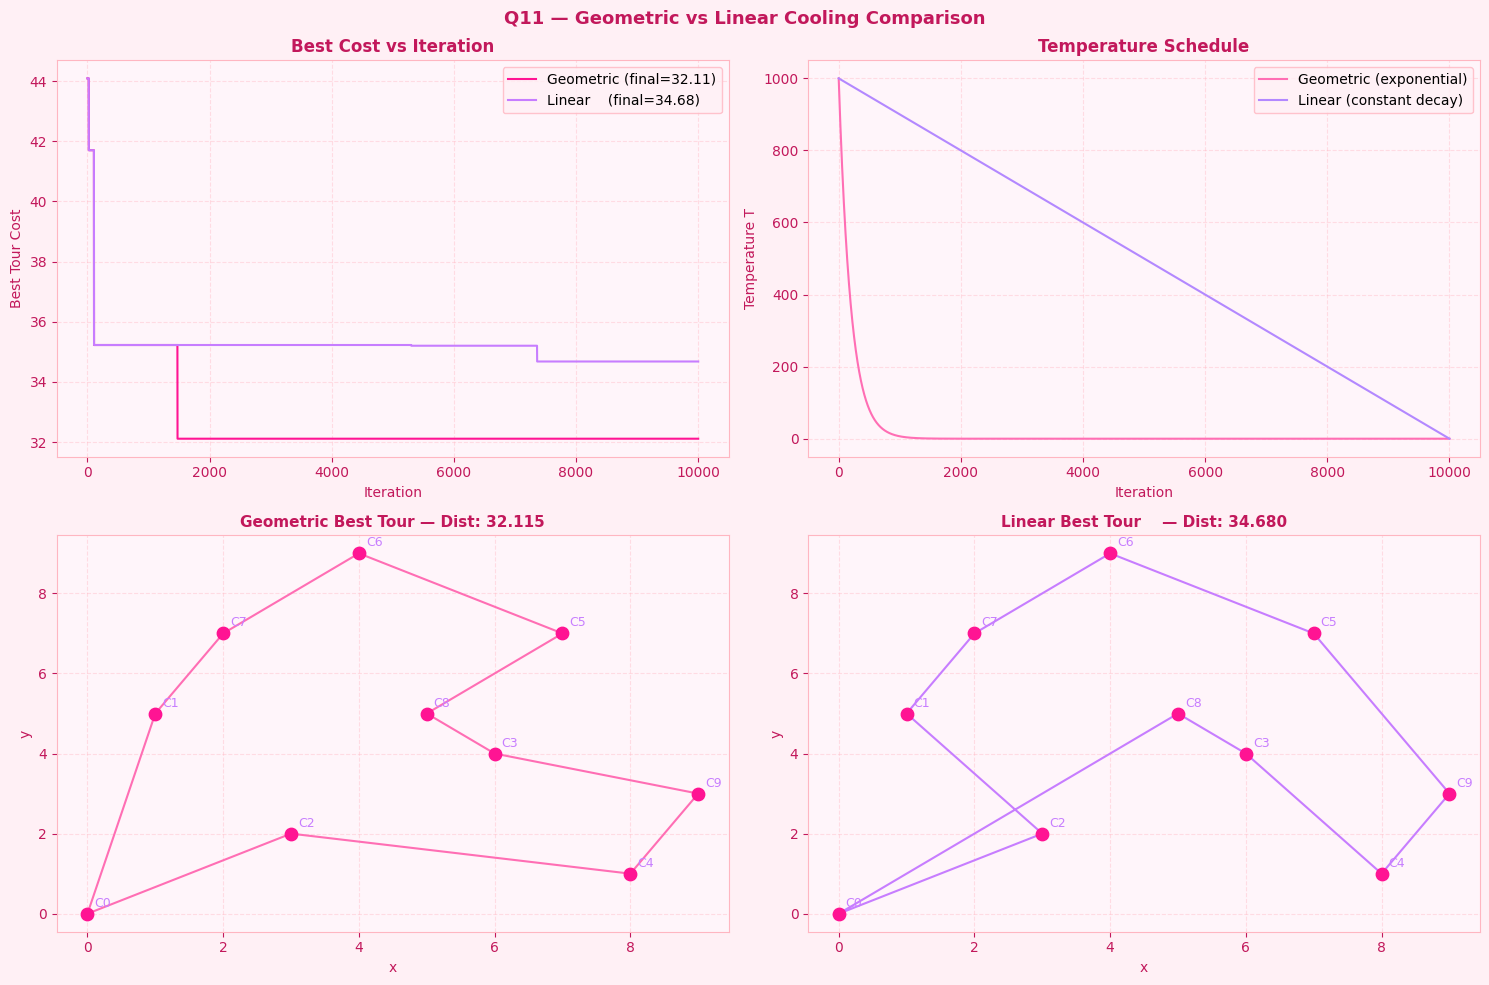

Graph saved: q11_comparison.png 


In [72]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.patch.set_facecolor('#FFF0F5')
for row in axes:
    for ax in row:
        ax.set_facecolor('#FFF5FA')
        ax.tick_params(colors='#C2185B')
        for spine in ax.spines.values():
            spine.set_color('#FFB6C1')

axes[0][0].plot(best_hist_geo, color='#FF1493', linewidth=1.5, label=f'Geometric (final={best_cost_geo:.2f})')
axes[0][0].plot(best_hist_lin, color='#C77DFF', linewidth=1.5, label=f'Linear    (final={best_cost_lin:.2f})')
axes[0][0].set_title('Best Cost vs Iteration', fontsize=12, color='#C2185B', fontweight='bold')
axes[0][0].set_xlabel('Iteration', color='#C2185B')
axes[0][0].set_ylabel('Best Tour Cost', color='#C2185B')
axes[0][0].legend(facecolor='#FFF0F5', edgecolor='#FFB6C1')
axes[0][0].grid(True, color='#FFB6C1', alpha=0.4, linestyle='--')

axes[0][1].plot(temp_hist_geo, color='#FF6EB4', linewidth=1.5, label='Geometric (exponential)')
axes[0][1].plot(temp_hist_lin, color='#B388FF', linewidth=1.5, label='Linear (constant decay)')
axes[0][1].set_title('Temperature Schedule', fontsize=12, color='#C2185B', fontweight='bold')
axes[0][1].set_xlabel('Iteration', color='#C2185B')
axes[0][1].set_ylabel('Temperature T', color='#C2185B')
axes[0][1].legend(facecolor='#FFF0F5', edgecolor='#FFB6C1')
axes[0][1].grid(True, color='#FFB6C1', alpha=0.4, linestyle='--')

def plot_tour(ax, tour, cities, title, color):
    coords = [cities[i] for i in tour] + [cities[tour[0]]]
    xs=[c[0] for c in coords]; ys=[c[1] for c in coords]
    ax.plot(xs, ys, '-o', color=color, markersize=8, linewidth=1.5)
    for i, ci in enumerate(tour):
        ax.annotate(f'C{ci}', cities[ci], textcoords='offset points',
                    xytext=(5,5), fontsize=9, color='#C77DFF')
    ax.scatter(*zip(*cities), color='#FF1493', zorder=5, s=80)
    ax.set_title(title, fontsize=11, color='#C2185B', fontweight='bold')
    ax.set_xlabel('x', color='#C2185B')
    ax.set_ylabel('y', color='#C2185B')
    ax.set_facecolor('#FFF5FA')
    ax.tick_params(colors='#C2185B')
    for spine in ax.spines.values():
        spine.set_color('#FFB6C1')
    ax.grid(True, color='#FFB6C1', alpha=0.4, linestyle='--')

plot_tour(axes[1][0], best_tour_geo, CITIES, f'Geometric Best Tour — Dist: {best_cost_geo:.3f}', '#FF6EB4')
plot_tour(axes[1][1], best_tour_lin, CITIES, f'Linear Best Tour    — Dist: {best_cost_lin:.3f}', '#C77DFF')

plt.suptitle('Q11 — Geometric vs Linear Cooling Comparison', fontsize=13,
             fontweight='bold', color='#C2185B')
plt.tight_layout()
plt.savefig('q11_comparison.png', dpi=150, bbox_inches='tight', facecolor='#FFF0F5')
plt.show()
print("Graph saved: q11_comparison.png ")

# Observations

-Geometric cooling finds better solutions because it explores more broadly before committing — the slow decay near the end allows fine-tuning

-Linear cooling converges faster but risks getting stuck in local optima early since temperature drops too quickly

-For this 10-city TSP, both may find similar results since the problem is small — the difference becomes more obvious on larger problems

-The temperature schedule plot clearly shows the difference — geometric is a curve, linear is a straight line dropping to zero

# Q12

# (A)

In [10]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")
import matplotlib.patches as patches
from collections import Counter

N=8; K=5; MAX_ITER=500; NUM_TRIALS=20
GOAL_H = N*(N-1)//2
print("--------------------------------------------------------------")

print(f"N={N}, K={K}, Goal h={GOAL_H}, Trials={NUM_TRIALS}")

2026-03-16 22:57:34.380095
F23-0885
--------------------------------------------------------------
--------------------------------------------------------------
N=8, K=5, Goal h=28, Trials=20


In [11]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")
def random_state(n=N):
    return [random.randint(0, n-1) for _ in range(n)]

def attacking_pairs(state):
    n=len(state); attacks=0
    for i in range(n):
        for j in range(i+1, n):
            if state[i]==state[j] or abs(state[i]-state[j])==abs(i-j):
                attacks+=1
    return attacks

def heuristic(state):
    n=len(state)
    return n*(n-1)//2 - attacking_pairs(state)

def get_successors(state):
    n=len(state); succs=[]
    for col in range(n):
        for row in range(n):
            if row != state[col]:
                ns=state[:]; ns[col]=row
                succs.append((heuristic(ns), ns))
    return succs

def is_goal(state): return heuristic(state)==GOAL_H

demo=random_state()
print("--------------------------------------------------------------")
print(f"Demo state : {demo}")
print(f"h value    : {heuristic(demo)} / {GOAL_H}")
print(f"Is goal?   : {is_goal(demo)}")
print("--------------------------------------------------------------")


2026-03-16 22:57:38.078423
F23-0885
--------------------------------------------------------------
--------------------------------------------------------------
Demo state : [0, 3, 5, 0, 6, 7, 5, 7]
h value    : 21 / 28
Is goal?   : False
--------------------------------------------------------------


# (B)

In [12]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")
def local_beam_search(k=K, max_iter=MAX_ITER, n=N, seed=None):
    if seed is not None: random.seed(seed)
    beams=[random_state(n) for _ in range(k)]
    h_history=[max(heuristic(s) for s in beams)]

    for iteration in range(1, max_iter+1):
        all_succs=[]
        for state in beams:
            if is_goal(state):
                return True, state, iteration-1, h_history, None
            all_succs.extend(get_successors(state))

        all_succs.sort(key=lambda x: x[0], reverse=True)
        seen=set(); top_k=[]
        for h_val, state in all_succs:
            key=tuple(state)
            if key not in seen:
                seen.add(key); top_k.append((h_val, state))
            if len(top_k)==k: break

        for h_val, state in top_k:
            if h_val==GOAL_H:
                h_history.append(h_val)
                return True, state, iteration, h_history, None

        new_best=top_k[0][0] if top_k else 0
        old_best=h_history[-1]
        h_history.append(new_best)
        beams=[state for _,state in top_k]

        if new_best<=old_best and iteration>10:
            failure="plateau" if new_best==old_best else "local_optimum"
            return False, beams[0], iteration, h_history, failure

    return False, beams[0], max_iter, h_history, "max_iterations"
print("--------------------------------------------------------------")
print("Local Beam Search function ready!")
print("--------------------------------------------------------------")


2026-03-16 22:57:41.673653
F23-0885
--------------------------------------------------------------
--------------------------------------------------------------
Local Beam Search function ready!
--------------------------------------------------------------


# (C)

In [13]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")
lbs_results=[]
for trial in range(NUM_TRIALS):
    success, sol, iters, hist, fail = local_beam_search(seed=trial*7)
    lbs_results.append({'trial':trial+1,'success':success,'iters':iters,
                         'h_final':heuristic(sol),'failure':fail,'history':hist})
    print("--------------------------------------------------------------")
    status='SUCCESS' if success else f'FAIL ({fail})'
    print(f"Trial {trial+1:02d}: {status} | iters={iters} | h={heuristic(sol)}")

successes=   [r for r in lbs_results if r['success']]
failures=    [r for r in lbs_results if not r['success']]
success_rate=len(successes)/NUM_TRIALS*100
avg_iters=   np.mean([r['iters'] for r in successes]) if successes else 0
fail_modes=  Counter([r['failure'] for r in failures])
print("--------------------------------------------------------------")
print(f"\n{'='*50}")
print(f"(i)  Success Rate          : {len(successes)}/{NUM_TRIALS} = {success_rate:.1f}%")
print("--------------------------------------------------------------")
print(f"(ii) Avg Iters (successes) : {avg_iters:.1f}")
print(f"(iii)Most Common Failure   : {fail_modes.most_common(1)[0] if fail_modes else 'None'}")
print(f"{'='*50}")
print("--------------------------------------------------------------")


2026-03-16 22:57:44.930572
F23-0885
--------------------------------------------------------------
--------------------------------------------------------------
Trial 01: SUCCESS | iters=3 | h=28
--------------------------------------------------------------
Trial 02: SUCCESS | iters=6 | h=28
--------------------------------------------------------------
Trial 03: SUCCESS | iters=3 | h=28
--------------------------------------------------------------
Trial 04: FAIL (plateau) | iters=11 | h=27
--------------------------------------------------------------
Trial 05: SUCCESS | iters=4 | h=28
--------------------------------------------------------------
Trial 06: SUCCESS | iters=3 | h=28
--------------------------------------------------------------
Trial 07: SUCCESS | iters=3 | h=28
--------------------------------------------------------------
Trial 08: SUCCESS | iters=5 | h=28
--------------------------------------------------------------
Trial 09: FAIL (plateau) | iters=11 | h=27
---

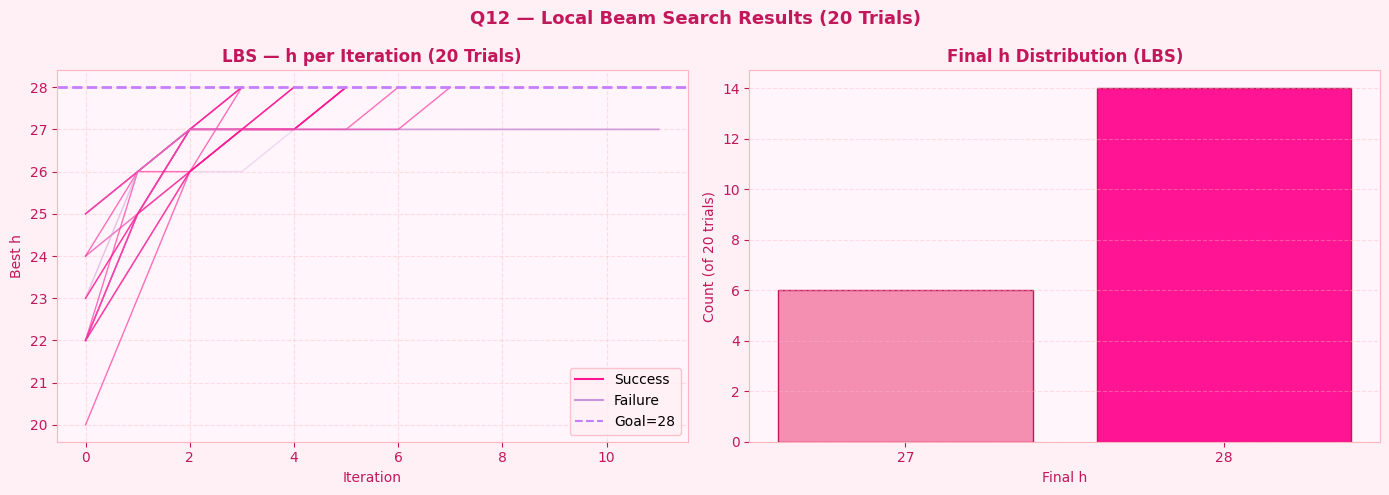

Graph saved: q12_lbs_results.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FFF0F5')
axes[0].set_facecolor('#FFF5FA')
axes[1].set_facecolor('#FFF5FA')
for ax in axes:
    ax.tick_params(colors='#C2185B')
    for spine in ax.spines.values():
        spine.set_color('#FFB6C1')

for r in lbs_results:
    color='#FF1493' if r['success'] else '#CE93D8'
    axes[0].plot(r['history'], color=color, alpha=0.6 if r['success'] else 0.3, linewidth=1)

axes[0].axhline(y=GOAL_H, color='#C77DFF', linestyle='--', linewidth=2, label=f'Goal h={GOAL_H}')
g  = plt.Line2D([0],[0], color='#FF1493', label='Success')
r_ = plt.Line2D([0],[0], color='#CE93D8', label='Failure')
axes[0].legend(handles=[g, r_, plt.Line2D([0],[0], color='#C77DFF', linestyle='--', label=f'Goal={GOAL_H}')],
               facecolor='#FFF0F5', edgecolor='#FFB6C1')
axes[0].set_title('LBS — h per Iteration (20 Trials)', fontsize=12, color='#C2185B', fontweight='bold')
axes[0].set_xlabel('Iteration', color='#C2185B')
axes[0].set_ylabel('Best h', color='#C2185B')
axes[0].grid(True, color='#FFB6C1', alpha=0.4, linestyle='--')

h_finals = Counter([r['h_final'] for r in lbs_results])
bars = sorted(h_finals.keys())
bar_colors = ['#FF1493' if b==GOAL_H else '#F48FB1' for b in bars]
axes[1].bar([str(b) for b in bars], [h_finals[b] for b in bars],
            color=bar_colors, edgecolor='#C2185B')
axes[1].set_title('Final h Distribution (LBS)', fontsize=12, color='#C2185B', fontweight='bold')
axes[1].set_xlabel('Final h', color='#C2185B')
axes[1].set_ylabel('Count (of 20 trials)', color='#C2185B')
axes[1].grid(True, color='#FFB6C1', alpha=0.4, linestyle='--', axis='y')

plt.suptitle('Q12 — Local Beam Search Results (20 Trials)', fontsize=13,
             fontweight='bold', color='#C2185B')
plt.tight_layout()
plt.savefig('q12_lbs_results.png', dpi=150, bbox_inches='tight', facecolor='#FFF0F5')
plt.show()
print("Graph saved: q12_lbs_results.png")

# (D)

In [14]:
from datetime import datetime
print(datetime.now())
print("F23-0885")
print("--------------------------------------------------------------")
def stochastic_beam_search(k=K, max_iter=MAX_ITER, n=N, seed=None):
    if seed is not None: random.seed(seed)
    beams=[random_state(n) for _ in range(k)]
    h_history=[max(heuristic(s) for s in beams)]

    for iteration in range(1, max_iter+1):
        all_succs=[]
        for state in beams:
            if is_goal(state):
                return True, state, iteration-1, h_history, None
            all_succs.extend(get_successors(state))

        for h_val, state in all_succs:
            if h_val==GOAL_H:
                h_history.append(h_val)
                return True, state, iteration, h_history, None

        if not all_succs:
            return False, beams[0], iteration, h_history, "no_successors"

        h_values=[h for h,_ in all_succs]
        min_h=min(h_values)
        weights=[h-min_h+1e-6 for h in h_values]
        total_w=sum(weights)
        probs=[w/total_w for w in weights]

        indices=list(range(len(all_succs)))
        chosen=random.choices(indices, weights=probs, k=min(k*5, len(indices)))
        seen=set(); selected=[]
        for idx in chosen:
            h_val, state = all_succs[idx]
            key=tuple(state)
            if key not in seen:
                seen.add(key); selected.append((h_val,state))
            if len(selected)==k: break

        if len(selected)<k:
            all_succs.sort(key=lambda x:x[0], reverse=True)
            for h_val,state in all_succs:
                key=tuple(state)
                if key not in seen:
                    seen.add(key); selected.append((h_val,state))
                if len(selected)==k: break

        new_best=max(h for h,_ in selected)
        old_best=h_history[-1]
        h_history.append(new_best)
        beams=[state for _,state in selected]

        if new_best<=old_best and iteration>10:
            failure="plateau" if new_best==old_best else "local_optimum"
            return False, beams[0], iteration, h_history, failure

    return False, beams[0], max_iter, h_history, "max_iterations"


sbs_results=[]
for trial in range(NUM_TRIALS):
    success, sol, iters, hist, fail = stochastic_beam_search(seed=trial*7)
    sbs_results.append({'trial':trial+1,'success':success,'iters':iters,
                         'h_final':heuristic(sol),'failure':fail,'history':hist})
    print("--------------------------------------------------------------")
    status='SUCCESS' if success else f'FAIL ({fail})'
    print(f"Trial {trial+1:02d}: {status} | iters={iters} | h={heuristic(sol)}")

sbs_successes=   [r for r in sbs_results if r['success']]
sbs_success_rate=len(sbs_successes)/NUM_TRIALS*100
sbs_avg_iters=   np.mean([r['iters'] for r in sbs_successes]) if sbs_successes else 0
sbs_fail_modes=  Counter([r['failure'] for r in sbs_results if not r['success']])
print("--------------------------------------------------------------")
print(f"\n{'='*50}")
print(f"SBS Success Rate : {len(sbs_successes)}/{NUM_TRIALS} = {sbs_success_rate:.1f}%")
print(f"LBS Success Rate : {len(successes)}/{NUM_TRIALS} = {success_rate:.1f}%")
print(f"SBS Avg Iters    : {sbs_avg_iters:.1f}")
print(f"SBS Fail Modes   : {dict(sbs_fail_modes)}")
print(f"{'='*50}")

2026-03-16 22:57:51.494153
F23-0885
--------------------------------------------------------------
--------------------------------------------------------------
Trial 01: FAIL (local_optimum) | iters=12 | h=25
--------------------------------------------------------------
Trial 02: FAIL (local_optimum) | iters=11 | h=21
--------------------------------------------------------------
Trial 03: FAIL (local_optimum) | iters=12 | h=23
--------------------------------------------------------------
Trial 04: FAIL (local_optimum) | iters=11 | h=21
--------------------------------------------------------------
Trial 05: FAIL (plateau) | iters=11 | h=22
--------------------------------------------------------------
Trial 06: FAIL (plateau) | iters=12 | h=24
--------------------------------------------------------------
Trial 07: SUCCESS | iters=5 | h=28
--------------------------------------------------------------
Trial 08: FAIL (plateau) | iters=11 | h=23
-------------------------------------

C:\Users\hp\AppData\Local\Temp\ipykernel_22504\4252083460.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([lbs_iters, sbs_iters], labels=['Local BS', 'Stochastic BS'],


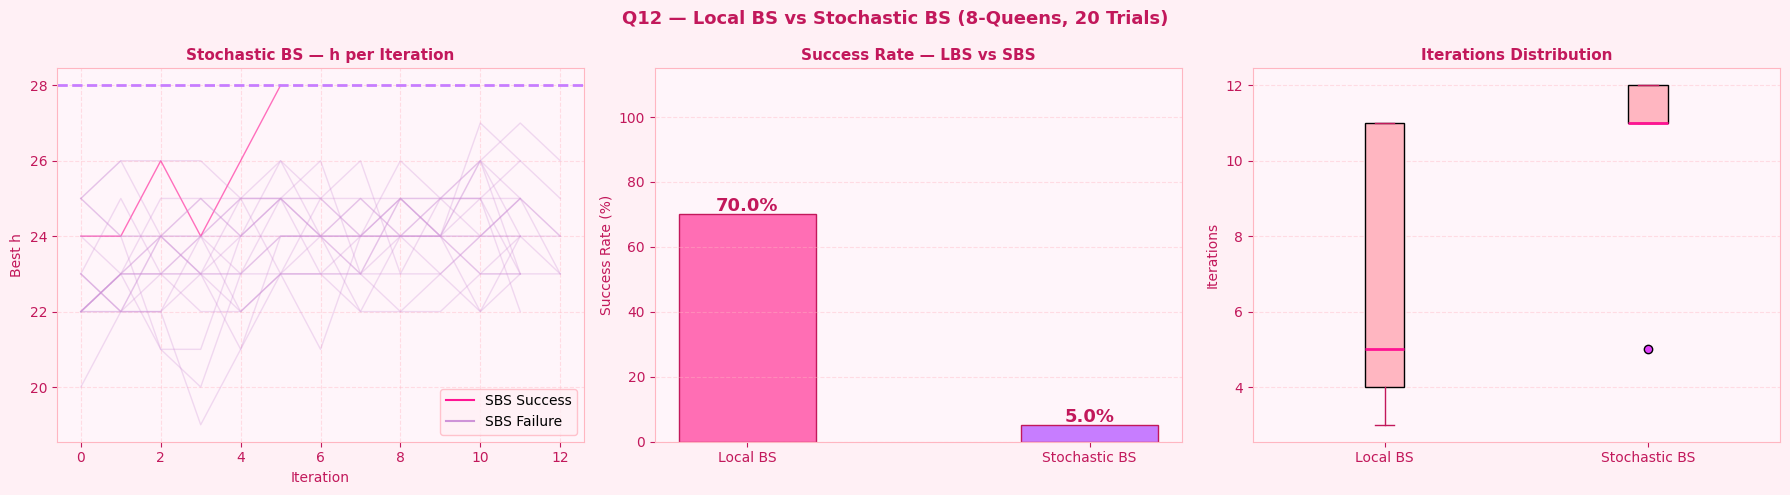

Graph saved: q12_comparison.png


In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#FFF0F5')
for ax in axes:
    ax.set_facecolor('#FFF5FA')
    ax.tick_params(colors='#C2185B')
    for spine in ax.spines.values():
        spine.set_color('#FFB6C1')

for r in sbs_results:
    color='#FF1493' if r['success'] else '#CE93D8'
    axes[0].plot(r['history'], color=color, alpha=0.6 if r['success'] else 0.3, linewidth=1)
axes[0].axhline(y=GOAL_H, color='#C77DFF', linestyle='--', linewidth=2)
axes[0].set_title('Stochastic BS — h per Iteration', fontsize=11, color='#C2185B', fontweight='bold')
axes[0].set_xlabel('Iteration', color='#C2185B')
axes[0].set_ylabel('Best h', color='#C2185B')
b = plt.Line2D([0],[0], color='#FF1493', label='SBS Success')
o = plt.Line2D([0],[0], color='#CE93D8', label='SBS Failure')
axes[0].legend(handles=[b, o], facecolor='#FFF0F5', edgecolor='#FFB6C1')
axes[0].grid(True, color='#FFB6C1', alpha=0.4, linestyle='--')

labels = ['Local BS', 'Stochastic BS']
rates  = [success_rate, sbs_success_rate]
bar_colors = ['#FF6EB4', '#C77DFF']
bars = axes[1].bar(labels, rates, color=bar_colors, edgecolor='#C2185B', width=0.4)
for bar, rate in zip(bars, rates):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=13, color='#C2185B')
axes[1].set_ylim(0, 115)
axes[1].set_title('Success Rate — LBS vs SBS', fontsize=11, color='#C2185B', fontweight='bold')
axes[1].set_ylabel('Success Rate (%)', color='#C2185B')
axes[1].grid(True, color='#FFB6C1', alpha=0.4, linestyle='--', axis='y')

lbs_iters = [r['iters'] for r in lbs_results]
sbs_iters = [r['iters'] for r in sbs_results]
axes[2].boxplot([lbs_iters, sbs_iters], labels=['Local BS', 'Stochastic BS'],
                patch_artist=True,
                boxprops=dict(facecolor='#FFB6C1'),
                medianprops=dict(color='#FF1493', linewidth=2),
                whiskerprops=dict(color='#C2185B'),
                capprops=dict(color='#C2185B'),
                flierprops=dict(markerfacecolor='#E040FB', marker='o'))
axes[2].set_title('Iterations Distribution', fontsize=11, color='#C2185B', fontweight='bold')
axes[2].set_ylabel('Iterations', color='#C2185B')
axes[2].grid(True, color='#FFB6C1', alpha=0.4, linestyle='--', axis='y')

plt.suptitle('Q12 — Local BS vs Stochastic BS (8-Queens, 20 Trials)',
             fontsize=13, fontweight='bold', color='#C2185B')
plt.tight_layout()
plt.savefig('q12_comparison.png', dpi=150, bbox_inches='tight', facecolor='#FFF0F5')
plt.show()
print("Graph saved: q12_comparison.png")

# Key Findings

SBS maintains diversity the biggest weakness of LBS is that all k beams end up in the same neighbourhood, effectively becoming one searcher. SBS prevents this

SBS escapes plateaus better when LBS hits a flat region, all k beams stall together. SBS can still sample states from other regions

SBS may take more iterations because it occasionally picks non-optimal states, it doesn't always climb as aggressively as LBS

Success rate improves over 20 trials SBS tends to find the goal state more often because it covers more of the search space

# REPORTS:

## Q10 Report
- **Simple HC** moves to the first improving neighbour fast but may take suboptimal paths
- **Steepest-Ascent HC** always picks the best neighbour more deliberate, same result on unimodal f
- **Random Restart** runs 10 times from different starts overkill here since f(x) is unimodal (one peak), every start converges to x=3
- **Does random restart always help?** No for unimodal smooth functions like this one, it wastes computation. It truly helps on multimodal landscapes with many local optima.

## Q11 Report
- **State:** permutation of city indices 
- **Neighbour:** swap 2 random cities
- **SA accepts worse moves** with P = e^(−ΔE/T) allows escaping local optima early on
- **Geometric cooling** decays slowly near the end more fine-tuning, generally better results
- **Linear cooling** drops temperature at a constant rate converges faster but may miss better solutions
- Cost vs iteration plot shows high variance early (high T = exploring) and stabilises at the end (low T = exploiting)

## Q12 Report
- **State:** list of rows per column 
- **h:** non-attacking pairs (goal = 28)
- **LBS** pools all successors from k beams → greedily picks top k fast but loses diversity quickly
- **Most common failure:** plateau all beams cluster at same region, no improvement possible
- **Stochastic BS** samples proportional to h preserves diversity, less likely to cluster
- SBS generally has **equal or better** success rate than LBS, but may take more iterations
- The boxplot shows SBS has a wider iteration spread it explores more before converging